# 温度駆動力を与える。固相液相の**多結晶**シミュレーションー＞GPU計算

In [41]:
import matplotlib.pyplot as plt
from numba import cuda
import math
import numpy as np

# --- 定数と設定 ---
nx, ny = 256, 256
number_of_grain = 10
dx, dy = 1e-4, 1e-4
dt = 0.01
nsteps = 1000000
pi = np.pi
scaling_factor = 1.0e-4
sigma = 1.0*scaling_factor
delta = 10.0 * dx
T_melt = 1687.15
G = 1.0e+02
V_pulling = 1.0e-05
latent = 4.15e+09*scaling_factor

aaa = 2.0 / pi * np.sqrt(2.0*delta*sigma)
www = 4 * sigma/delta
pmobi = pi*pi/(8.*delta)*3.0e-13

In [42]:
# パラメータ配列の準備
wij = np.zeros((number_of_grain, number_of_grain), dtype=np.float32)
aij = np.zeros((number_of_grain, number_of_grain), dtype=np.float32)
mij = np.zeros((number_of_grain, number_of_grain), dtype=np.float32)

for i in range(number_of_grain):
    for j in range(number_of_grain):
        if i == j: continue
        wij[i,j] = www
        aij[i,j] = aaa
        if (i == 0 and j != 0) or (i != 0 and j == 0):
            mij[i,j] = pmobi /scaling_factor
        else:
            mij[i,j] = pmobi

In [ ]:
# --- CUDA Kernels ---
@cuda.jit
def kernel_update_phasefield(phi, phi_new, temp, wij, aij, mij, nx, ny, number_of_grain, dx, dt, T_melt, latent):
    l, m = cuda.grid(2)
    if l < nx and m < ny:
        # x方向は周期境界条件
        l_p = l + 1 if l < nx - 1 else 0
        l_m = l - 1 if l > 0 else nx - 1
        # y方向はノイマン境界条件
        m_p = m + 1 if m < ny - 1 else m
        m_m = m - 1 if m > 0 else 0
        # 各フェーズの更新
        for i in range(number_of_grain):
            dpi = 0.0
            num_phase = 0
            # 存在しているフェーズ数をカウント（nfに相当）
            for k in range(number_of_grain):
                threshold = 1e-6
                if phi[k, l, m] > threshold or phi[k, l_p, m] > threshold or phi[k, l_m, m] > threshold or phi[k, l, m_p] > threshold or phi[k, l, m_m] > threshold:
                    num_phase += 1
            
            if num_phase <= 1 and phi[i, l, m] >= 1.0:
                phi_new[i, l, m] = phi[i, l, m]
                continue

            for j in range(number_of_grain):
                if i == j: continue
                
                # 駆動力の計算
                driving_force = 0.0
                curr_temp = temp[l, m]
                if i != 0 and j == 0:
                    driving_force = latent * (T_melt - curr_temp) / T_melt
                elif i == 0 and j != 0:
                    driving_force = -1.0 * latent * (T_melt - curr_temp) / T_melt

                # pppの計算 (Σ term1 + term2)
                ppp = 0.0
                for k in range(number_of_grain):
                    lap_phi_k = (phi[k, l_p, m] + phi[k, l_m, m] + phi[k, l, m_p] + phi[k, l, m_m] - 4.0 * phi[k, l, m]) / (dx * dx)
                    term1 = (wij[i, k] - wij[j, k]) * phi[k, l, m]
                    term2 = 0.5 * (aij[i, k]**2 - aij[j, k]**2) * lap_phi_k
                    ppp += term1 + term2
                
                phii_phij = phi[i, l, m] * phi[j, l, m]
                # math.sqrtの中に負が入らないようガード
                term_force = (8.0 / 3.1415926535) * math.sqrt(max(phii_phij, 0.0)) * driving_force
                dpi -= (2.0 / float(num_phase)) * mij[i, j] * (ppp - term_force)
            
            phi_new[i, l, m] = phi[i, l, m] + dpi * dt

        # 簡易的な正規化 (一貫性のため)
        sum_phi = 0.0
        for i in range(number_of_grain):
            if phi_new[i, l, m] < 0: phi_new[i, l, m] = 0
            sum_phi += phi_new[i, l, m]
        
        if sum_phi > 0:
            for i in range(number_of_grain):
                phi_new[i, l, m] /= sum_phi

In [44]:
@cuda.jit
def kernel_update_temp(temp, cooling_rate, nx, ny):
    l, m = cuda.grid(2)
    if l < nx and m < ny:
        temp[l, m] -= cooling_rate

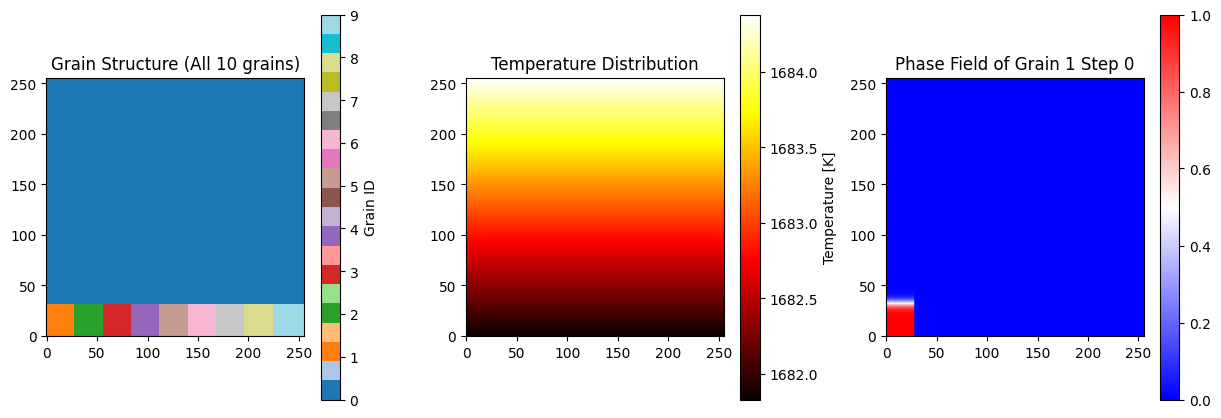

In [ ]:
# --- 初期化 ---
phi_cpu = np.zeros((number_of_grain, nx, ny), dtype=np.float32)
# (初期配置のロジックは質問のものをそのまま使用)
seed_height = 32
factor = 2 / delta

number_of_solidgrains = number_of_grain - 1 # 結晶粒の数
grain_width = nx // number_of_solidgrains

for l in range(nx):
    # X座標に基づいて、どの固相IDに属するか決める
    # 例: l=0~30 -> ID=1, l=31~60 -> ID=2 ...
    grain_id = int(l // grain_width) + 1
    if grain_id > number_of_solidgrains:
        grain_id = number_of_solidgrains
    for m in range(ny):
        y = m * dy
        dist = y - (seed_height * dy)
        phi_solid = 0.5 * (1.0 - np.tanh(factor * dist))
        phi_cpu[grain_id, l, m] = phi_solid
        phi_cpu[0, l, m] = 1.0 - phi_solid

temp_cpu = np.zeros((nx, ny), dtype=np.float32)
for m in range(ny):
    temp_cpu[:, m] = T_melt + G * (m - seed_height) * dy

phase_map = np.argmax(phi_cpu, axis=0)

fig = plt.figure(figsize=(15, 5))
plt.subplots_adjust(wspace=0.3) 

# 1. 結晶粒マップ (Grain Map)
plt.subplot(1, 3, 1)
# 'tab20' や 'nipy_spectral' などの多色カラーマップを使うと綺麗に分かれます
# 液相(0)と固相(1~)が別の色で表示されます
plt.imshow(phase_map.T, cmap='tab20', origin='lower', interpolation='nearest')
plt.colorbar(ticks=range(number_of_grain), label='Grain ID')
plt.title(f"Grain Structure (All {number_of_grain} grains)")

# 2. 温度場 (Temperature)
plt.subplot(1, 3, 2)
plt.imshow(temp_cpu.T, cmap='hot', origin='lower')
plt.colorbar(label='Temperature [K]')
plt.title("Temperature Distribution")
plt.subplot(1,3,3)
plt.imshow(phi_cpu[1].T, cmap='bwr', origin='lower',vmax=1.0,vmin=0.0)
plt.colorbar()
plt.title("Phase Field of Grain 1 Step 0")
plt.savefig("result/periodic/step_0.png")
plt.show()
plt.close()

plt.show()

In [46]:
# GPUメモリへ転送
d_phi = cuda.to_device(phi_cpu)
d_phi_new = cuda.to_device(phi_cpu)
d_temp = cuda.to_device(temp_cpu)
d_wij = cuda.to_device(wij)
d_aij = cuda.to_device(aij)
d_mij = cuda.to_device(mij)

In [47]:
# CUDA実行構成
threadsperblock = (16, 16)
blockspergrid_x = math.ceil(nx / threadsperblock[0])
blockspergrid_y = math.ceil(ny / threadsperblock[1])
blockspergrid = (blockspergrid_x, blockspergrid_y)

Step 10000 done.


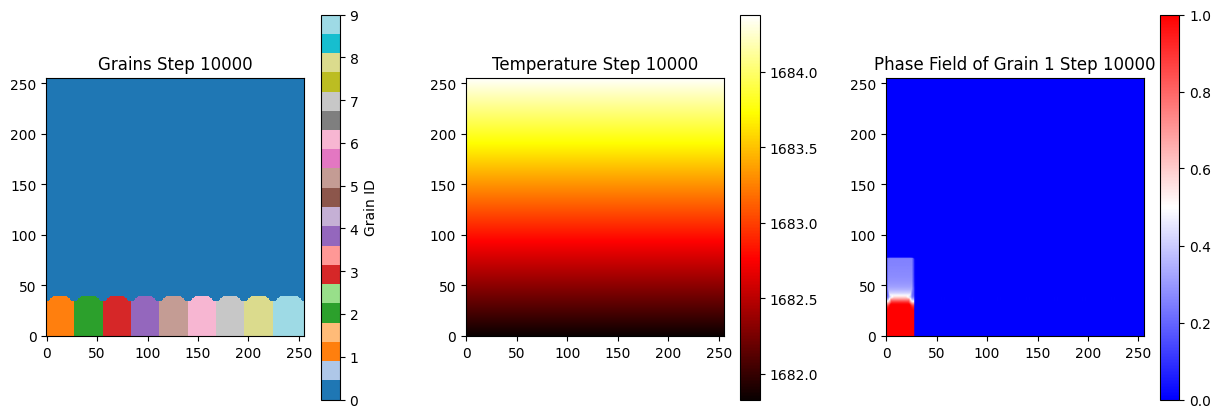

Step 20000 done.


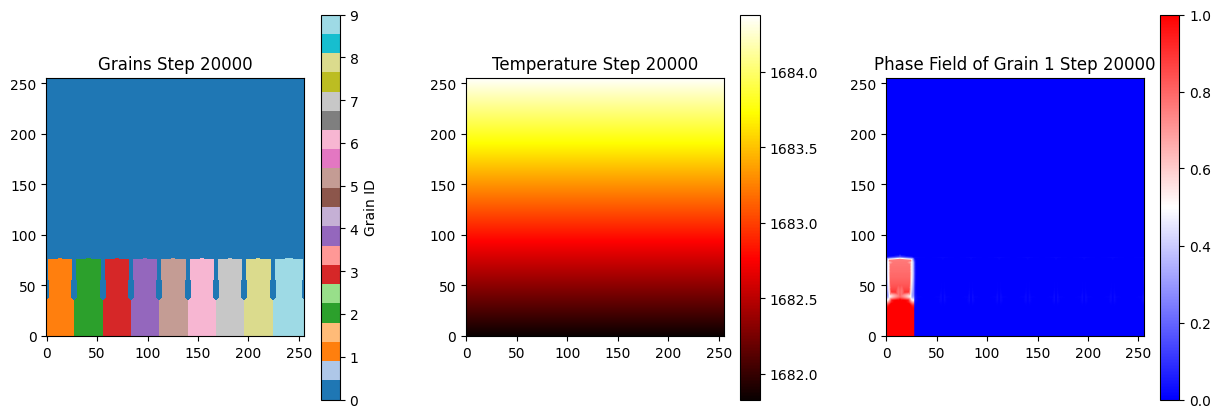

Step 30000 done.


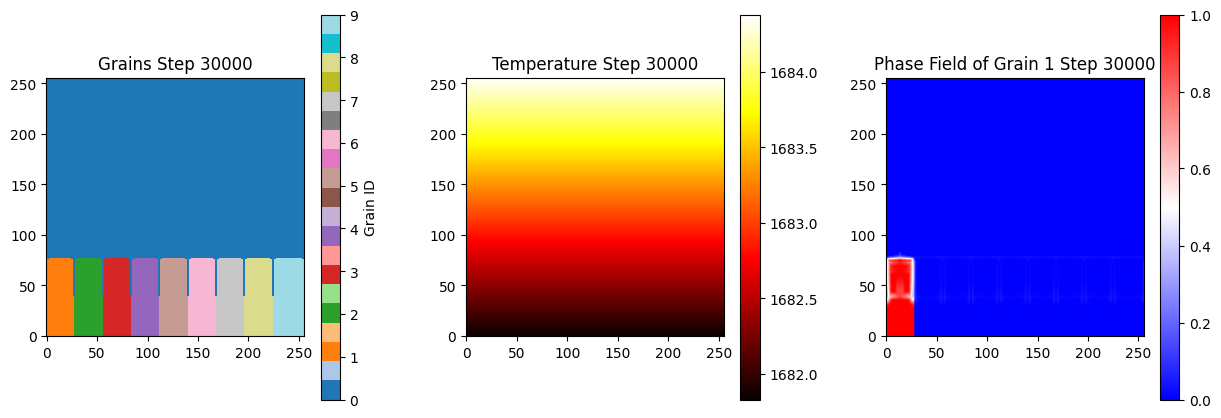

Step 40000 done.


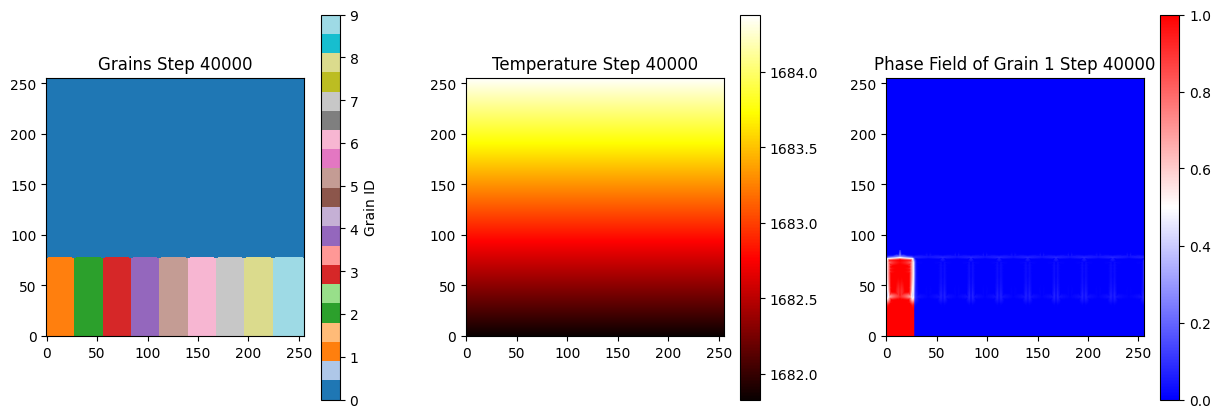

Step 50000 done.


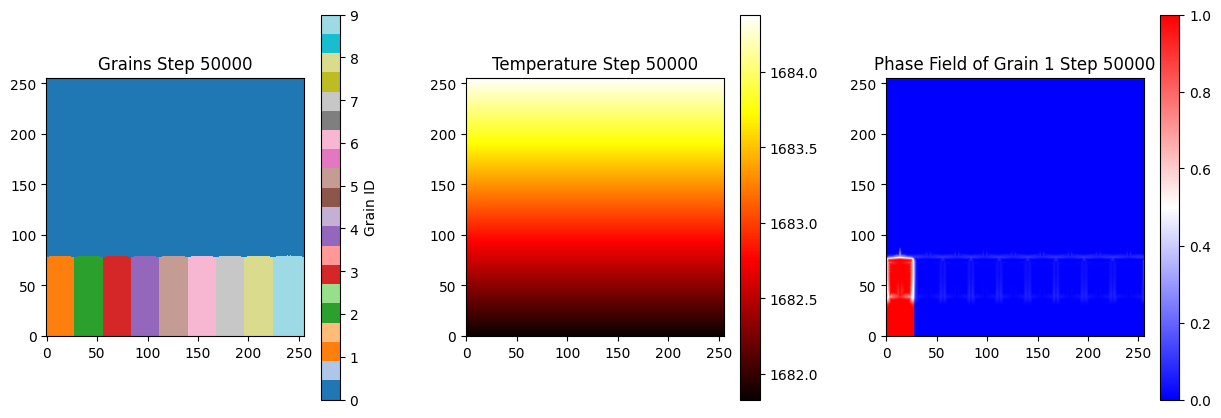

Step 60000 done.


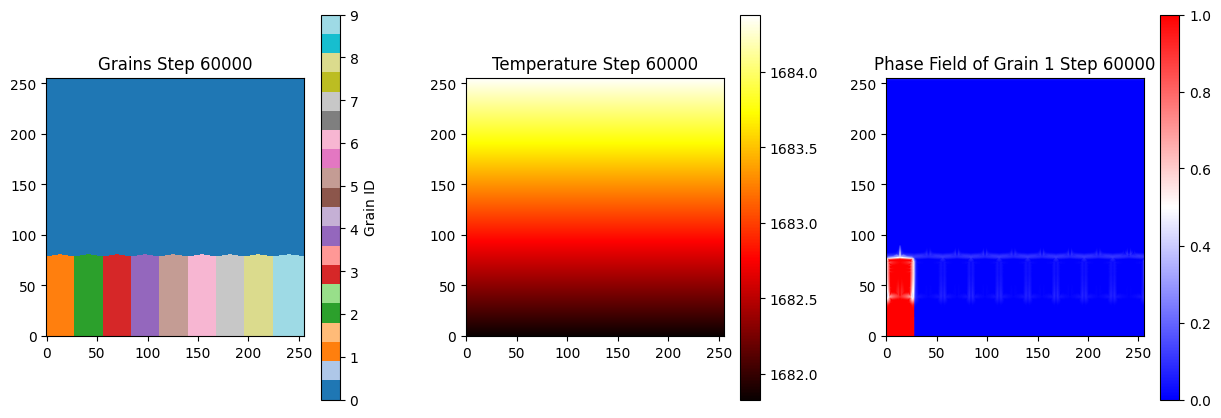

Step 70000 done.


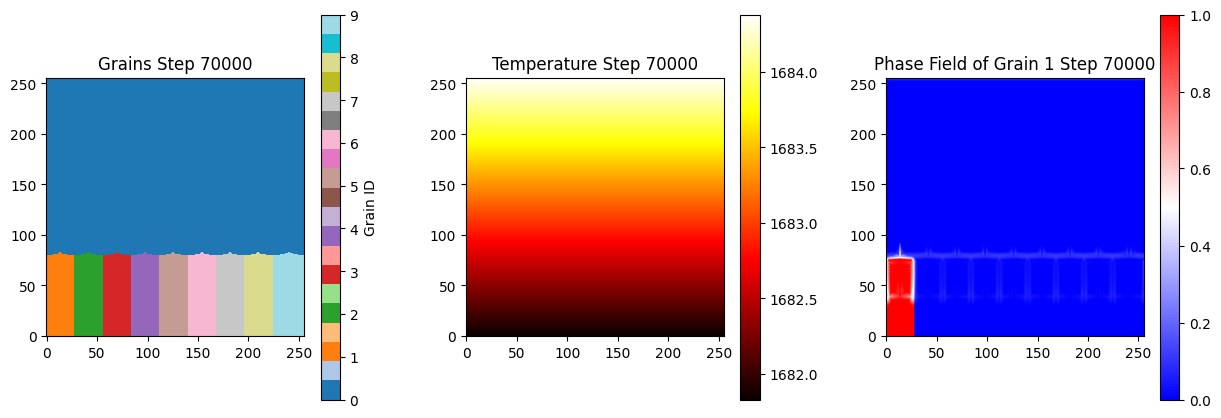

Step 80000 done.


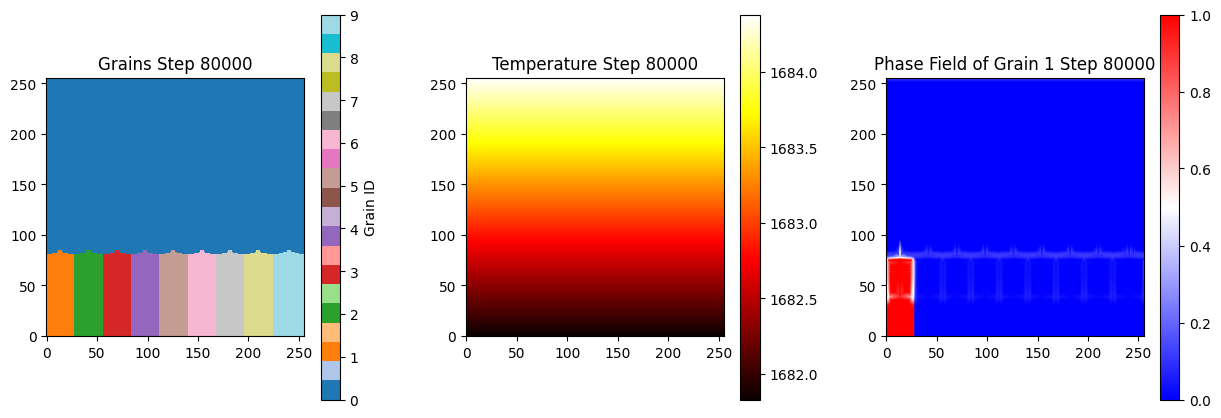

Step 90000 done.


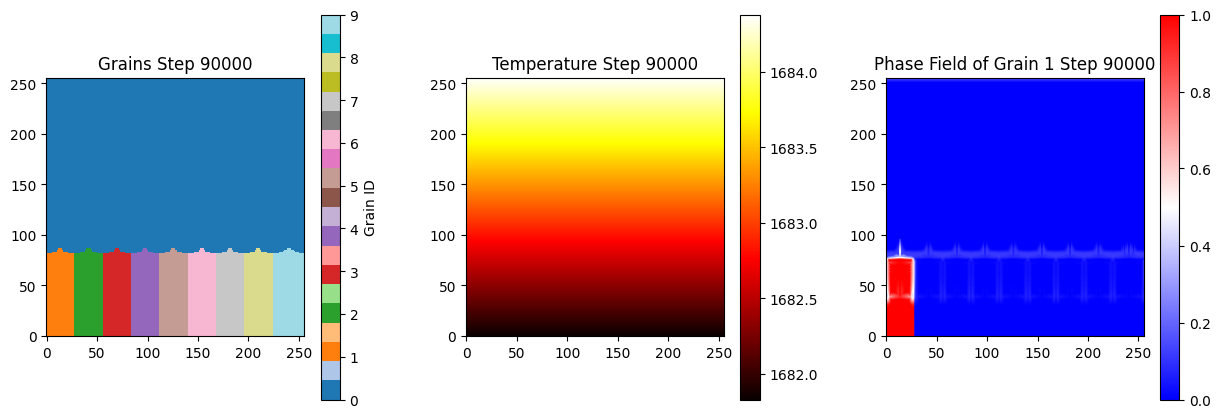

Step 100000 done.


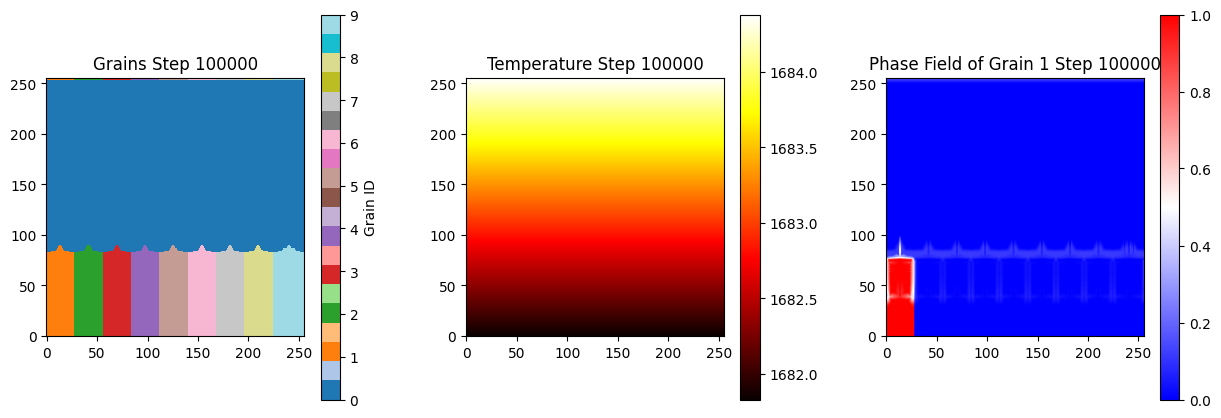

Step 110000 done.


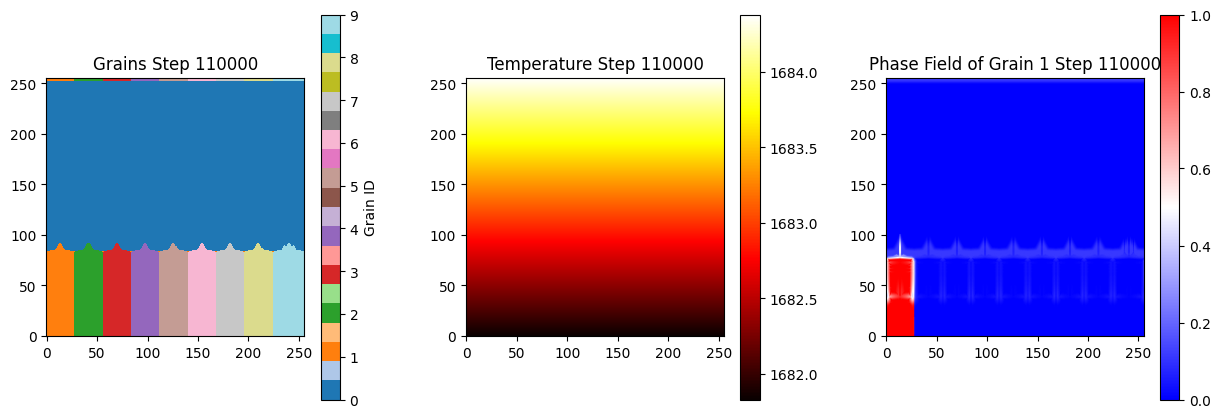

Step 120000 done.


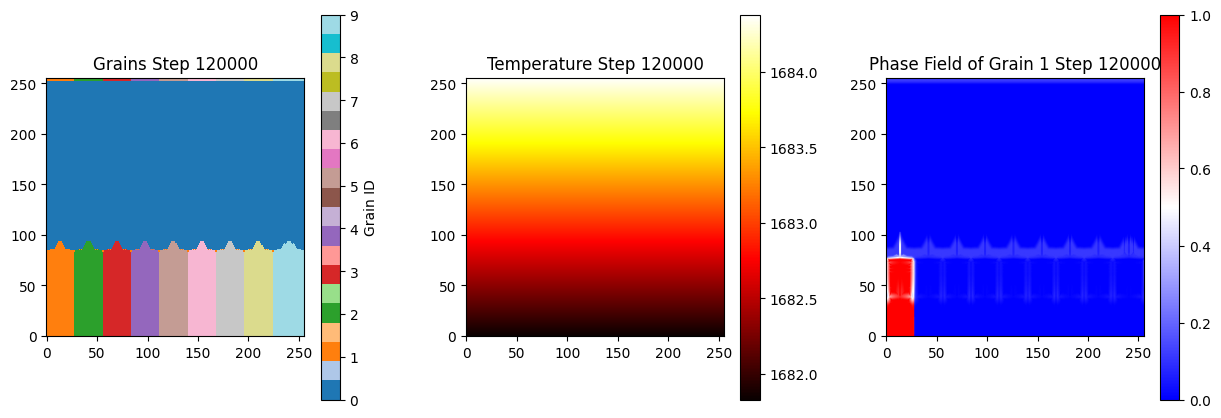

Step 130000 done.


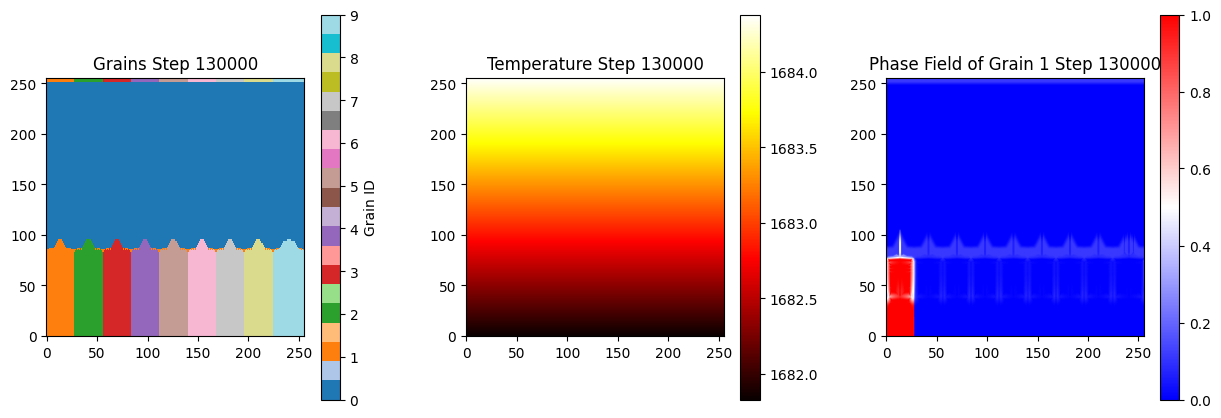

KeyboardInterrupt: 

In [48]:
# --- メインループ ---
cooling_rate = G * V_pulling * dt

for nstep in range(1, nsteps + 1):
    # 温度更新
    kernel_update_temp[blockspergrid, threadsperblock](d_temp, cooling_rate, nx, ny)
    
    # フェーズフィールド更新
    kernel_update_phasefield[blockspergrid, threadsperblock](
        d_phi, d_phi_new, d_temp, d_wij, d_aij, d_mij, nx, ny, number_of_grain, dx, dt, T_melt, latent
    )
    
    # ポインタの入れ替え（d_phiに最新結果を入れる）
    d_phi, d_phi_new = d_phi_new, d_phi

    if nstep % 10000 == 0:
        current_phi = d_phi.copy_to_host()
        current_temp = d_temp.copy_to_host()
        print(f"Step {nstep} done.")
        phase_map = np.argmax(current_phi, axis=0)
    
        fig = plt.figure(figsize=(15,5))
        plt.subplots_adjust(wspace=0.3) 
        plt.subplot(1,3,1)
        plt.imshow(phase_map.T, cmap='tab20', origin='lower', interpolation='nearest')
        plt.colorbar(ticks=range(number_of_grain), label='Grain ID')
        plt.title(f"Grains Step {nstep}")

        plt.subplot(1,3,2)
        plt.imshow(current_temp.T, cmap='hot', origin='lower')
        plt.title(f"Temperature Step {nstep}")
        plt.colorbar()
        plt.subplot(1,3,3)
        plt.imshow(current_phi[1].T, cmap='bwr', origin='lower',vmax=1.0,vmin=0.0)
        plt.colorbar()
        plt.title(f"Phase Field of Grain 1 Step {nstep}")
        plt.savefig(f"result/periodic/step_{nstep}.png")
        plt.show()
        plt.close()
